---
(Multiple) Regressions
---

In this tutorial you will learn to run regressions with statsmodels.

## Linear regressions

## Part 1: Income and education

__Import the Duncan/carData dataset__

In [1]:
# Import statsmodels and load the Duncan dataset from the carData R package
import statsmodels.api as sm
dataset = sm.datasets.get_rdataset("Duncan", "carData", cache=True)
df = dataset.data
df.head()  # Display first 5 rows to preview data
df.info()  # Show data types, non-null counts, and memory usage

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, accountant to waiter
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   type       45 non-null     object
 1   income     45 non-null     int64 
 2   education  45 non-null     int64 
 3   prestige   45 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.8+ KB


In [ ]:
# Display summary statistics: mean, std, min, max, and quartiles for all variables
df.describe()

,income,education,prestige
count,45.000000,45.000000,45.000000
mean,41.866667,52.555556,47.688889
std,24.435072,29.760831,31.510332
min,7.000000,7.000000,3.000000
25%,21.000000,26.000000,16.000000
50%,42.000000,45.000000,41.000000
75%,64.000000,84.000000,81.000000
max,81.000000,100.000000,97.000000


__Estimate by hand the model $\text{income} = \alpha + \beta  \times \text{education}$ . Plot.__

---

## OLS Reminder

We estimate the linear model

$y_i = \alpha + \beta x_i + \varepsilon_i$
 
$y =$ income  
$x =$ education


### Formulas

Slope:
$\beta = \frac{Cov(y,x)}{Var(x)}$

Intercept:
$\alpha = \bar y - \beta \bar x$

Prediction:
$\hat y_i = \alpha + \beta x_i$



OLS chooses the line minimizing squared errors:
$\sum_i (y_i - \hat y_i)^2$


---


Below we compute $\alpha$ and $\beta$ manually before plotting the fitted line. This is not needed in general as the libraries compute all of that for us.

In [2]:
# Calculate covariance matrix for income and education 
# (needed for OLS formula)
Σ = df[ ['income', 'education'] ].cov()
Σ

,income,education
income,597.072727,526.871212
education,526.871212,885.707071


In [3]:
# Calculate sample means for income and education 
# (used in intercept calculation)
μ = df[ ['income', 'education'] ].mean()
μ

income       41.866667
education    52.555556
dtype: float64

In [ ]:
# Calculate slope coefficient β using OLS formula: β = Cov(y,x) / Var(x)
β = Σ.loc['income','education'] / Σ.loc['education','education']
β  # Display the calculated slope value


np.float64(0.5948594400410561)

In [ ]:
# Calculate intercept α using formula: α = mean(y) - β * mean(x)
α = μ['income'] - β*μ['education']
α # Display the calculated intercept value


np.float64(10.603498317842273)

In [7]:
# Generate predicted values of income based on estimated coefficients
# ŷ = α + β * education
prediction = α + β*df['education']

Text(0, 0.5, 'Income')

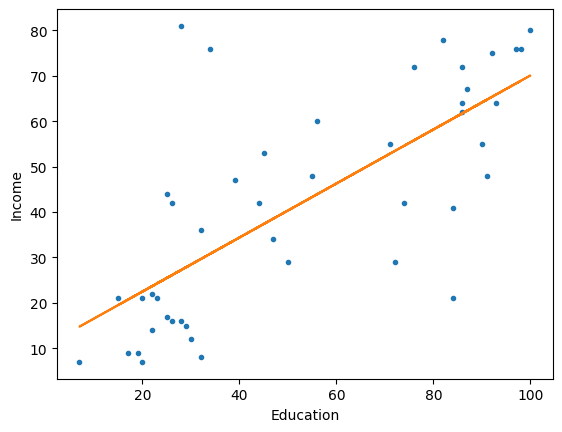

In [9]:
# Plot the regression: scatter plot of actual data and fitted regression line
from matplotlib import pyplot as plt
plt.plot(df['education'], df['income'], '.')  # Plot observed data points
plt.plot(df['education'], prediction)  # Plot fitted regression line
plt.xlabel('Education')  # Label x-axis
plt.ylabel('Income')  # Label y-axis


__Compute total, explained, unexplained variance. Compute R^2 statistics__

---

### Variance Decomposition & $R^2$ Reminder

We check how much of income variation is explained by the fitted line.

$y$ = actual income  
$\hat y$ = predicted income  
$e = y - \hat y$ = residual

##### Decomposition

$TSS = \sum_i (y_i - \bar y)^2$

$ESS = \sum_i (\hat y_i - \bar y)^2$

$RSS = \sum_i (y_i - \hat y_i)^2$

$TSS = ESS + RSS$



##### Goodness of Fit

$R^2 = \frac{ESS}{TSS} = 1 - \frac{RSS}{TSS}$

Share of income variation explained by education.


---

Same as before. We do it only to check that the formulas yield the same results as the libraries used below.

In [10]:
# Store fitted values and residuals in dataframe for variance decomposition
df['prediction'] = α + β*df['education']

# Residuals = actual - predicted
df['residual'] = df['income'] - df['prediction']


In [11]:
# Calculate covariance matrix with prediction and residuals for variance analysis
Sigma = df[['income', 'education', 'prediction', 'residual']].cov()

In [12]:
# Extract variance components: total (TSS), explained (ESS), and unexplained (RSS)
# Recall: TSS = ESS + RSS

total_variance = Sigma.loc['income', 'income']            # Var(y)  -> TSS / n
prediction_variance = Sigma.loc['prediction', 'prediction']  # Var(ŷ) -> ESS / n
residual_variance = Sigma.loc['residual', 'residual']        # Var(e) -> RSS / n


In [13]:
# Display total variance of outcome variable (TSS / n)
print(total_variance.round(2))

# Display variance explained by the model (ESS / n)
print(prediction_variance.round(2))

# Display variance unexplained by the model (RSS / n)
print(residual_variance.round(2))

# Verify variance decomposition: TSS = ESS + RSS
print(prediction_variance + residual_variance)

# Calculate R² manually: share of variance explained
# R² = 1 - RSS/TSS
myRsquared = 1 - residual_variance / total_variance
print(myRsquared.round(2))


597.07
313.41
283.66
597.0727272727274
0.52


__Use statsmodels (formula API) to estimate $\text{income} = \alpha + \beta  \times \text{education}$. Comment regression statistics.__

In [14]:
# Estimate OLS using statsmodels formula API (R-style syntax: y ~ x)
import statsmodels.formula.api as smf

model_1 = smf.ols("income ~ education", data=df)  # Define regression model
res_1 = model_1.fit()  # Estimate coefficients (α̂, β̂)


In [16]:
# Display full regression results: coefficients, p-values, confidence intervals, R²
print(res_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     47.51
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           1.84e-08
Time:                        11:01:55   Log-Likelihood:                -190.42
No. Observations:                  45   AIC:                             384.8
Df Residuals:                      43   BIC:                             388.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.6035      5.198      2.040      0.0



***Interpreting the output***

Estimated regression:

$\widehat{income} = 10.6 + 0.59 \times education$

- Each additional year of education increases income by about **0.59 units on average**
- Both coefficients are statistically significant (p < 0.05)
- $R^2 = 0.52$ → education explains about half of the income variation




__Use statsmodels to estimate $\text{income} = \alpha + \beta  \times \text{prestige}$. Comment regression statistics.__

In [19]:
# Estimate regression with prestige as predictor instead
# This allows comparison of model fit across different regressors
model_2 = smf.ols("income ~ prestige", df)
res_2 = model_2.fit()

In [21]:
# Display results for prestige model to compare with education model
print(res_2.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.695
Method:                 Least Squares   F-statistic:                     101.3
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           7.14e-13
Time:                        11:04:28   Log-Likelihood:                -179.93
No. Observations:                  45   AIC:                             363.9
Df Residuals:                      43   BIC:                             367.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.8840      3.678      2.959      0.0


**Interpreting the output**

Estimated regression:

$\widehat{income} = 10.88 + 0.65 \times prestige$

- A one-unit increase in prestige increases income by about **0.65 units on average**
- Both coefficients are statistically significant (p < 0.01)
- $R^2 = 0.70$ → prestige explains about 70% of the income variation


__Use statsmodels to estimate $\text{income} = \alpha + \beta  \times \text{education}  + \beta_2  \times \text{prestige}  + $. Comment regression statistics.__

In [22]:
# Estimate multiple regression with both education and prestige
# This helps identify multicollinearity issues between predictors
model_3 = smf.ols("income ~ education + prestige", df)
res_3 = model_3.fit()

In [24]:
# Display multiple regression results
print(res_3.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     49.55
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           8.88e-12
Time:                        11:05:11   Log-Likelihood:                -179.90
No. Observations:                  45   AIC:                             365.8
Df Residuals:                      42   BIC:                             371.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.4264      4.164      2.504      0.0

***Interpreting the output***

$\widehat{income} = 10.43 + 0.03 \times education + 0.62 \times prestige$

- Holding prestige constant, education has **no significant effect** (p = 0.81)
- Prestige remains strongly significant → income mainly varies with prestige
- $R^2 = 0.70$ → the model explains about 70% of income variation

The $R^2$ is only slightly higher than in the previous model, but the adjusted $R^2$ is lower → the model has less predictive power.

The coefficient for `education` is not significant and should be dropped from the regression.

This may occur because education and prestige are correlated. Let's check it.


In [25]:
# Check correlation between education and prestige
# High correlation indicates multicollinearity problem in multiple regression
df[['prestige','education']].corr()

,prestige,education
prestige,1.000000,0.851916
education,0.851916,1.000000


The correlation matrix shows a strong relationship between education and prestige (≈ 0.85).

This means the two variables contain very similar information. When both are included
in the regression, the model struggles to isolate their separate effects. 

As a result,
standard errors increase and one variable (education) becomes statistically insignificant.

This is a typical multicollinearity situation.


__WHich model would you recommend? For which purpose?__

- **Prediction:** use the model with prestige only → highest predictive power
- **Effect of education:** use the model with education only

The choice of regression depends on the objective: prediction vs interpretation.

__Plot the regression with prestige__

In [30]:
# Extract prestige variable for visualization of regression
x = df['prestige']

In [31]:
# Extract estimated coefficients from regression results
# Calculate predicted values manually: ŷ = a + b*x
a = res_2.params.Intercept
b = res_2.params.prestige
y = a + b*x

In [32]:
# Alternative: use predict() method for fitted values (cleaner approach)
y = res_2.predict(x)

Text(0, 0.5, 'income')

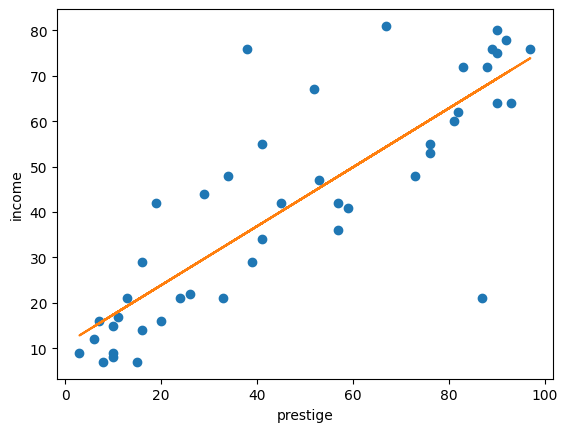

In [33]:
# Plot regression results: scatter of actual data with fitted line
from matplotlib import pyplot as plt
plt.plot(x, df['income'], 'o')  # Scatter plot of observed data
plt.plot(x, y)  # Fitted regression line
plt.xlabel("prestige")  # X-axis label
plt.ylabel("income")  # Y-axis label

The relationship between prestige and income looks approximately linear,
so a linear model seems reasonable.

However, a good visual fit does NOT guarantee that the estimated coefficient
represents a causal effect.


__Check visually normality of residuals__

In [34]:
# Calculate residuals for diagnostic analysis
# Residuals = actual values - predicted values (equivalent to res_2.resid)
pred = a + b*x
actual = df['income']
resid = actual - pred

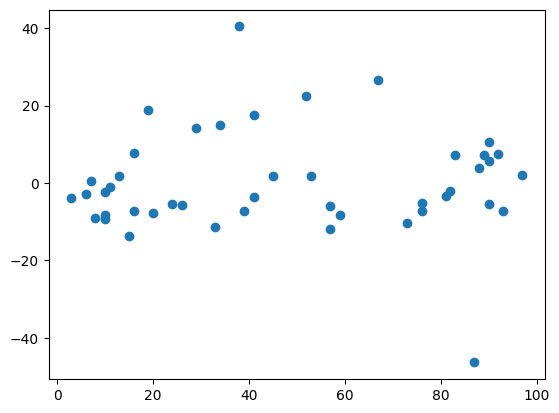

In [35]:
# Plot residuals against fitted values to check for heteroscedasticity and patterns
# Well-behaved residuals should appear as random scatter around zero
plt.plot(x, resid, 'o')

Residuals are not perfectly random around zero.

This suggests the model may be missing relevant variables affecting income.
If important factors are omitted and correlated with prestige, the coefficient
may be biased.

Good fit ≠ correct causal interpretation.


(array([ 1.,  0.,  0.,  2., 19., 11.,  6.,  4.,  1.,  1.]),
 array([-46.40643935, -37.72299114, -29.03954294, -20.35609473,
        -11.67264653,  -2.98919832,   5.69424989,  14.37769809,
         23.0611463 ,  31.74459451,  40.42804271]),
 <BarContainer object of 10 artists>)

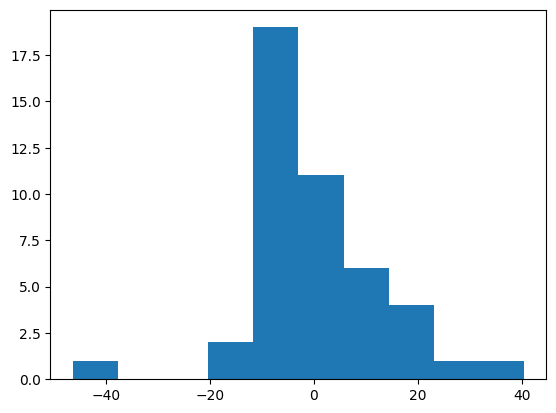

In [36]:
# Histogram of residuals to check normality assumption
# For OLS inference, residuals should be approximately normally distributed
plt.hist(resid)

OLS estimates describe associations in the data.
They only measure causal effects if the regressor is independent from omitted factors.

Next week we introduce instrumental variables to recover causal effects
when regressors are correlated with unobserved determinants of income.



## Part 2: Taylor Rule

__Import macro data from statsmodels (https://www.statsmodels.org/devel/datasets/generated/macrodata.html)__

In [47]:
# Import statsmodels to access built-in datasets including macroeconomic data
import statsmodels

In [48]:
# Import statsmodels API for regression analysis
import statsmodels.api as sm

In [49]:
# Access macrodata module containing quarterly US macroeconomic data
sm.datasets.macrodata

<module 'statsmodels.datasets.macrodata' from 'c:\\Users\\ezgio\\AppData\\Local\\Programs\\Python\\Python314\\Lib\\site-packages\\statsmodels\\datasets\\macrodata\\__init__.py'>

In [50]:
# Load macrodata into memory as pandas dataframe
ds = sm.datasets.macrodata.load_pandas()

In [51]:
# Extract raw data from dataset object and preview
df = ds.raw_data
df.head()  # Display first 5 rows

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


__Create a database with all variables of interest including detrended gdp__

In [52]:
# Extract key variables needed for Taylor Rule regression
gdp = df['realgdp']  # Real GDP
inflation = df['infl']  # Inflation rate
realint = df['realint']  # Real interest rate

In [53]:
# Copy dataframe for analysis (will add computed variables like interest rate and output gap)
ddf = df

In [54]:
# Preview the dataframe structure and contents
ddf.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


We use the fisher relation: $r_t = i_t - \pi_t$

In [55]:
# Calculate nominal interest rate using Fisher equation: i = r + π
# where i is nominal rate, r is real rate, and π is inflation
ddf['ir'] = ddf['realint'] + ddf['infl']

to detrend the gdp, we use hp-filter function from scipy google: hpfilter scipy. This is a classical tool in macroeconomics.

In [56]:
# Import Hodrick-Prescott filter for trend-cycle decomposition
# HP filter is a classical tool in macroeconomics to extract business cycles
from statsmodels.tsa.filters.hp_filter import hpfilter

In [57]:
# Apply HP filter to decompose GDP into trend and cyclical components
# cycle = deviations from trend (business cycle), trend = long-run path
cycle, trend = hpfilter(ddf['realgdp'])

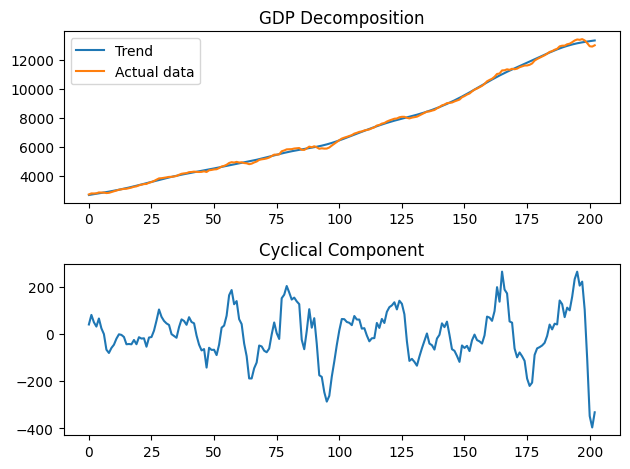

In [58]:
# Visualize trend-cycle decomposition of GDP
# Upper plot: trend line vs actual data; Lower plot: cyclical component alone
plt.subplot(211)
plt.plot(trend, label='Trend')
plt.plot(trend+cycle, label='Actual data')
plt.title("GDP Decomposition")
plt.legend(loc='upper left')
plt.subplot(212)
plt.plot(cycle)
plt.title("Cyclical Component")
plt.tight_layout()

In [59]:
# Create output gap variable: (cycle / trend) * 100 as percentage
# Output gap measures deviation of actual GDP from potential GDP
ddf['gdp'] = cycle/trend*100

In [60]:
# Preview updated dataframe with newly computed variables (ir and gdp)
ddf.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint,ir,gdp
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00,0.00,1.479383
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74,3.08,2.967657
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09,3.83,1.792534
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06,4.33,1.110571
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19,3.50,2.331547


__Run the basic regression__

In [61]:
# Import formula API for specifying regressions using R-style notation
from statsmodels.formula import api as sm

In [62]:
# Estimate basic Taylor Rule: nominal rate = f(inflation, output gap)
# Tests whether policy rate responds to inflation and economic slack
# "-1" suppresses the intercept (alternative specification without constant term)
model = sm.ols("ir ~ infl + gdp - 1", data=ddf)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                     ir   R-squared (uncentered):                   0.757
Model:                            OLS   Adj. R-squared (uncentered):              0.755
Method:                 Least Squares   F-statistic:                              313.1
Date:                Sat, 14 Feb 2026   Prob (F-statistic):                    1.80e-62
Time:                        13:30:38   Log-Likelihood:                         -508.16
No. Observations:                 203   AIC:                                      1020.
Df Residuals:                     201   BIC:                                      1027.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
infl           1.0294      0.041     24.858      0.000       0.948       1.111
gdp           -0.2266      0.137     -1.658      0.099      -0.496       0.043
==============================================================================
Omnibus:                        9.306   Durbin-Watson:                   0.807
Prob(Omnibus):                  0.010   Jarque-Bera (JB):               15.908
Skew:                           0.197   Prob(JB):                     0.000351
Kurtosis:                       4.313   Cond. No.                         3.37
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

__Which control variables would you propose to add? Does it increase prediction power? How do you interpret that?__

In [63]:
# Check available variables in dataframe for selecting controls
ddf.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint,ir,gdp
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00,0.00,1.479383
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74,3.08,2.967657
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09,3.83,1.792534
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06,4.33,1.110571
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19,3.50,2.331547


In [64]:
# Extended Taylor Rule with control variables (population and unemployment)
# Tests robustness of inflation and output gap coefficients to other factors
# Population (pop) and unemployment (unemp) added as control variables
model = sm.ols("ir ~ infl + gdp + pop + unemp - 1", data=ddf)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                     ir   R-squared (uncentered):                   0.884
Model:                            OLS   Adj. R-squared (uncentered):              0.882
Method:                 Least Squares   F-statistic:                              380.2
Date:                Sat, 14 Feb 2026   Prob (F-statistic):                    5.64e-92
Time:                        13:30:40   Log-Likelihood:                         -432.84
No. Observations:                 203   AIC:                                      873.7
Df Residuals:                     199   BIC:                                      886.9
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
infl           0.4380      0.049      8.895      0.000       0.341       0.535
gdp            0.5710      0.120      4.739      0.000       0.333       0.809
pop           -0.0050      0.002     -2.068      0.040      -0.010      -0.000
unemp          0.8064      0.108      7.458      0.000       0.593       1.020
==============================================================================
Omnibus:                        5.307   Durbin-Watson:                   0.391
Prob(Omnibus):                  0.070   Jarque-Bera (JB):                7.501
Skew:                           0.070   Prob(JB):                       0.0235
Kurtosis:                       3.931   Cond. No.                         247.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

At confidence level 2.5% gdp is between 0.333 and 0.809.

At confidence level 2.5% infl is between 0.341 and 0.535.

The coefficients would be significantly different from 0.5 if 0.5 was not in the condifence interval.